# Selección de Modelo – Sign Language MNIST

Tras el análisis exploratorio realizado en el notebook anterior, se identificó una fuerte redundancia espacial en el espacio original de 784 píxeles y se validó que aproximadamente 113 componentes principales permiten retener el 95% de la varianza sin pérdida morfológica significativa.

**El objetivo de esta fase será determinar:** 
- Si la reducción de dimensionalidad mejora el rendimiento predictivo.
- Qué nivel de compresión parece más efectivo.
- Qué modelos se adaptan mejor a la estructura del dataset.
- Qué tipos de errores son más frecuentes entre clases similares.

Los resultados obtenidos permitirán seleccionar un modelo final que será evaluado posteriormente sobre el conjunto de test.

## 1. Hipótesis y Metodología Experimental 

### 1.1 Hipótesis de Trabajo

Para este proyecto, se plantean las siguientes hipótesis basadas en los hallazgos del análisis exploratorio previo:

- **H1 (Reducción de dimensionalidad)**: Dado que 113 componentes principales explican el 95% de la varianza, se hipotetiza que una reducción a este nivel mantendrá el rendimiento predictivo extrayendo un subespacio suficiente del espacio original (784 px). Sin embargo, una reducción excesiva (p. ej., <50 componentes) degradará el F1-Score debido a la pérdida de rasgos morfológicos críticos para diferenciar clases similares.
  
- **H2 (No Linealidad)**: El solapamiento observado en las proyecciones iniciales sugiere que las fronteras de decisión son inherentemente no lineales. Se postula que los modelos con kernels no lineales (SVM-RBF) o arquitecturas jerárquicas (MLP) superarán significativamente a la Regresión Logística en términos de F1-Score Macro.

- **H3 (Agrupamiento Espacial)**: Se asume que el dataset, al ser imágenes normalizadas y centradas, presenta una estructura de clústeres compactos. Por tanto, un clasificador basado en distancias (k-NN) debería mostrar una alta precisión, siempre que el número de vecinos sea lo suficientemente bajo para no capturar muestras de clases solapadas en las fronteras.

### 1.2 Metodología Experimental

#### A. Instrumentos y Métodos de Validación
- **Validación Cruzada**: Stratified K-Fold ($k=5$) para asegurar la representatividad de las 24 clases en cada partición y reducir el sesgo de selección.
- **Pipeline de Procesamiento**: Cada fold incluirá un escalado estándar (StandardScaler) y una transformación PCA, ajustados exclusivamente en los datos de entrenamiento para evitar data leakage.
- **Métricas de Evaluación**: El F1-Score Macro será el indicador primario. A diferencia de la exactitud global, este indicador penaliza el rendimiento deficiente en clases individuales. Esto es vital en este proyecto: no buscamos un modelo que reconozca bien las señas "fáciles", sino uno que sea capaz de distinguir con precisión aquellas con alta similitud morfológica, como el par 'M' y 'N'.

#### B. Modelos Candidatos

Dado que el problema implica distinguir señas con alta similitud visual, el objetivo es evaluar cómo diferentes naturalezas algorítmicas resuelven la separación de clases en un espacio de características reducido por PCA.

- **Modelos de Referencia (Baselines)**  
    - **Regresión Logística (Baseline Lineal)**
        - Se utiliza para establecer el rendimiento mínimo esperado. Permite determinar si las señas pueden separarse mediante hiperplanos simples en el espacio de componentes principales.
    - **K-Nearest Neighbors (Referencia Local)**
        - Es crucial para entender la topología del espacio. Si las letras similares se agrupan en regiones compactas, KNN será muy efectivo. Nos dirá qué tan "cerca" están realmente una 'M' de una 'N' en términos de distancia euclidiana.

- **Modelos de Alta Capacidad (No lineales)**
    - **Support Vector Machine -con kernel RBF-**
        - Se incluye por su capacidad de proyectar los datos a dimensiones superiores. Es ideal para encontrar el margen óptimo de separación en casos de solapamiento crítico, donde el "ruido" de las sombras de los dedos o pequeñas rotaciones de la mano confunden a los modelos lineales.
    - **Perceptrón Multicapa (MLP)**
        - Representa el enfoque de aprendizaje profundo. Al ser una red neuronal densa, puede aprender combinaciones jerárquicas de los componentes del PCA. Es interesante explorar si el MLP logra sintetizar patrones espaciales que los modelos estadísticos tradicionales no capturan.

- **Modelos de Agregación y Robustez (Ensembles)**
    - **Random Forest**
        - Se selecciona como el exponente principal de los métodos de bagging. Al promediar múltiples árboles de decisión, es especialmente robusto frente a variaciones menores en las imágenes (ruido visual) y busca evitar el sobreajuste.

#### C. Definición del Espacio de Búsqueda
El espacio de búsqueda se diseñó para testear los límites de las hipótesis planteadas. 

| Modelo | Hiperparámetro | Ragno / Valores | Justificación técnica |
|--------|------|--------|--------|
| Global | `n_components`(PCA) | [35, 58, 113] | Controla el umbral de pérdida de información (H1). |
| logistic_regression | `C`(Regularización) | [0.1, 1, 5] | Controla la flexibilidad del hiperplano (H2)|
| k-NN | `n_neighbors` | [3, 5, 7] | Test de la densidad local de las clases (H3). |
| SVM | `C` (Regularización) | [0.1, 1, 5] | Control de la flexibilidad de la frontera no lineal (H2). |
| RF | `n_estimators` | [50, 100]| Evaluación de la convergencia del ensamble en espacios de alta y baja dimensionalidad. |
| MLP | `hidden_layers_sizes`| [(128,), (256, 128) ] | Comparación entre representaciones simples y profundas de características extraídas. |

## 2. Configuración Inicial

In [96]:
import sys
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import itertools


sys.path.append(os.path.abspath(".."))

import src.config as config
from src.train import run
from src.data_utils import plot_model_performance, get_best_representative

## 3. Definición del Espacio de Búsqueda

**Nota**: Dado que 113 componentes representan el 95% de la varianza dentro del set de datos que utilizamos, este escenario constituye la 'mejor oportunidad' para un clasificador lineal. Si la Regresión Logística no logra resultados competitivos bajo estas condiciones óptimas, se confirmará la necesidad de modelos no lineales (H2), permitiéndonos descartar pruebas adicionales con menor dimensionalidad (35 y 58 componentes) para este algoritmo específico.

In [2]:
pca_components = [35, 58, 113]
experiment_grid = [
    {
        "model_name": "logistic_regression",
        "params": {"C": [0.1, 1, 5]}, 
        "n_components": pca_components
    },
    {
        "model_name": "knn",
        "params": {"n_neighbors": [3, 5, 7]},
        "n_components": pca_components
    },
    {
        "model_name": "svm_rbf",
        "params": {"C": [0.1, 1, 5]},
        "n_components": pca_components
    },
    {
        "model_name": "rf",
        "params": {"n_estimators": [50, 100], "max_depth": [None, 20]},
        "n_components": pca_components
    },
    {
        "model_name": "mlp",
        "params": {"hidden_layer_sizes": [(128,), (256, 128)]},
        "n_components": pca_components
    }
]

## 4. Ejecución del Protocolo Experimental

Para asegurar que los resultados sean analizables, implementaremos un bucle anidado que extraiga los parámetros de experiment_grid. Utilizaremos la librería itertools.product para generar todas las combinaciones posibles de parámetros de forma limpia. Además, aseguramos que `model_dispatcher`iguale las condiciones de los modelos configurando:

- `random_state`= 42
- `max_iter`= 500
- `tol`= 1e-4

In [3]:
all_results = []

print(f"Iniciando protocolo experimental: {len(experiment_grid)} arquitecturas base.")

for experiment in experiment_grid:
    model_name = experiment["model_name"]
    components_list = experiment["n_components"]
    
    param_names = list(experiment["params"].keys())
    param_values = list(experiment["params"].values())
    
    # Cartesian Product 
    for values in itertools.product(*param_values):
        current_params = dict(zip(param_names, values))
        
        for n_comp in components_list:
            print(f"Ejecutando: {model_name} | PCA: {n_comp} | Params: {current_params}")
            
            for fold in range(5):
                result = run(
                    fold=fold, 
                    model=model_name, 
                    n_components=n_comp, 
                    **current_params
                )
                all_results.append(result)

results_df = pd.DataFrame(all_results)

Iniciando protocolo experimental: 5 arquitecturas base.
Ejecutando: logistic_regression | PCA: 35 | Params: {'C': 0.1}


/home/abril/miniconda3/envs/signlang/lib/python3.10/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/abril/miniconda3/envs/signlang/lib/python3.10/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/abril/miniconda3/envs/signlang/lib/python3.10/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/abril/miniconda3/envs/signlang/lib/python3.10/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/abril/miniconda3/envs/signlang/lib/python3.10/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.w

Ejecutando: logistic_regression | PCA: 58 | Params: {'C': 0.1}


/home/abril/miniconda3/envs/signlang/lib/python3.10/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/abril/miniconda3/envs/signlang/lib/python3.10/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/abril/miniconda3/envs/signlang/lib/python3.10/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/abril/miniconda3/envs/signlang/lib/python3.10/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/abril/miniconda3/envs/signlang/lib/python3.10/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.w

Ejecutando: logistic_regression | PCA: 113 | Params: {'C': 0.1}


...

Ejecutando: logistic_regression | PCA: 58 | Params: {'C': 5}


/home/abril/miniconda3/envs/signlang/lib/python3.10/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/abril/miniconda3/envs/signlang/lib/python3.10/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/abril/miniconda3/envs/signlang/lib/python3.10/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/abril/miniconda3/envs/signlang/lib/python3.10/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/abril/miniconda3/envs/signlang/lib/python3.10/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.w

Ejecutando: logistic_regression | PCA: 113 | Params: {'C': 5}


/home/abril/miniconda3/envs/signlang/lib/python3.10/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/abril/miniconda3/envs/signlang/lib/python3.10/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/abril/miniconda3/envs/signlang/lib/python3.10/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/abril/miniconda3/envs/signlang/lib/python3.10/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/abril/miniconda3/envs/signlang/lib/python3.10/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.w

Ejecutando: knn | PCA: 35 | Params: {'n_neighbors': 3}
Ejecutando: knn | PCA: 58 | Params: {'n_neighbors': 3}
Ejecutando: knn | PCA: 113 | Params: {'n_neighbors': 3}
Ejecutando: knn | PCA: 35 | Params: {'n_neighbors': 5}
Ejecutando: knn | PCA: 58 | Params: {'n_neighbors': 5}
Ejecutando: knn | PCA: 113 | Params: {'n_neighbors': 5}
Ejecutando: knn | PCA: 35 | Params: {'n_neighbors': 7}
Ejecutando: knn | PCA: 58 | Params: {'n_neighbors': 7}
Ejecutando: knn | PCA: 113 | Params: {'n_neighbors': 7}
Ejecutando: svm_rbf | PCA: 35 | Params: {'C': 0.1}
Ejecutando: svm_rbf | PCA: 58 | Params: {'C': 0.1}
Ejecutando: svm_rbf | PCA: 113 | Params: {'C': 0.1}
Ejecutando: svm_rbf | PCA: 35 | Params: {'C': 1}
Ejecutando: svm_rbf | PCA: 58 | Params: {'C': 1}
Ejecutando: svm_rbf | PCA: 113 | Params: {'C': 1}
Ejecutando: svm_rbf | PCA: 35 | Params: {'C': 5}
Ejecutando: svm_rbf | PCA: 58 | Params: {'C': 5}
Ejecutando: svm_rbf | PCA: 113 | Params: {'C': 5}
Ejecutando: rf | PCA: 35 | Params: {'n_estimators': 

## 5. Análisis de Resultados

In [42]:
results_df = pd.DataFrame(all_results)
results_df[results_df['model']=='logistic_regression']

,fold,model,n_components,macro_f1,accuracy,fit_time,model_size_mb,confusion_matrix,C,n_neighbors,n_estimators,max_depth,hidden_layer_sizes
0,0,logistic_regression,35,0.808168,0.806410,56.079893,0.007575,"[[204, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 3, 6, 0, ...",0.1,NaN,NaN,NaN,NaN
1,1,logistic_regression,35,0.816850,0.815334,53.296530,0.007575,"[[201, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 6, 5, 0, ...",0.1,NaN,NaN,NaN,NaN
2,2,logistic_regression,35,0.824311,0.823347,53.541110,0.007575,"[[203, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 6, 5, 0, ...",0.1,NaN,NaN,NaN,NaN
3,3,logistic_regression,35,0.823342,0.820798,54.712517,0.007575,"[[204, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 4, 0, ...",0.1,NaN,NaN,NaN,NaN
4,4,logistic_regression,35,0.816840,0.815334,53.611396,0.007575,"[[207, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 4, 1, 1, ...",0.1,NaN,NaN,NaN,NaN
5,0,logistic_regression,58,0.945863,0.944819,82.350465,0.011786,"[[223, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, ...",0.1,NaN,NaN,NaN,NaN
6,1,logistic_regression,58,0.955773,0.955017,82.158874,0.011786,"[[224, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, ...",0.1,NaN,NaN,NaN,NaN
7,2,logistic_regression,58,0.956036,0.955382,83.237289,0.011786,"[[225, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",0.1,NaN,NaN,NaN,NaN
8,3,logistic_regression,58,0.947240,0.946458,83.767437,0.011786,"[[224, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",0.1,NaN,NaN,NaN,NaN
9,4,logistic_regression,58,0.949173,0.948279,83.984322,0.011786,"[[225, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, ...",0.1,NaN,NaN,NaN,NaN


### 5.1. Análisis Intra-Modelo (Optimización de Hiperparámetros)

#### A. LR: Parámetro de Regularización `C`

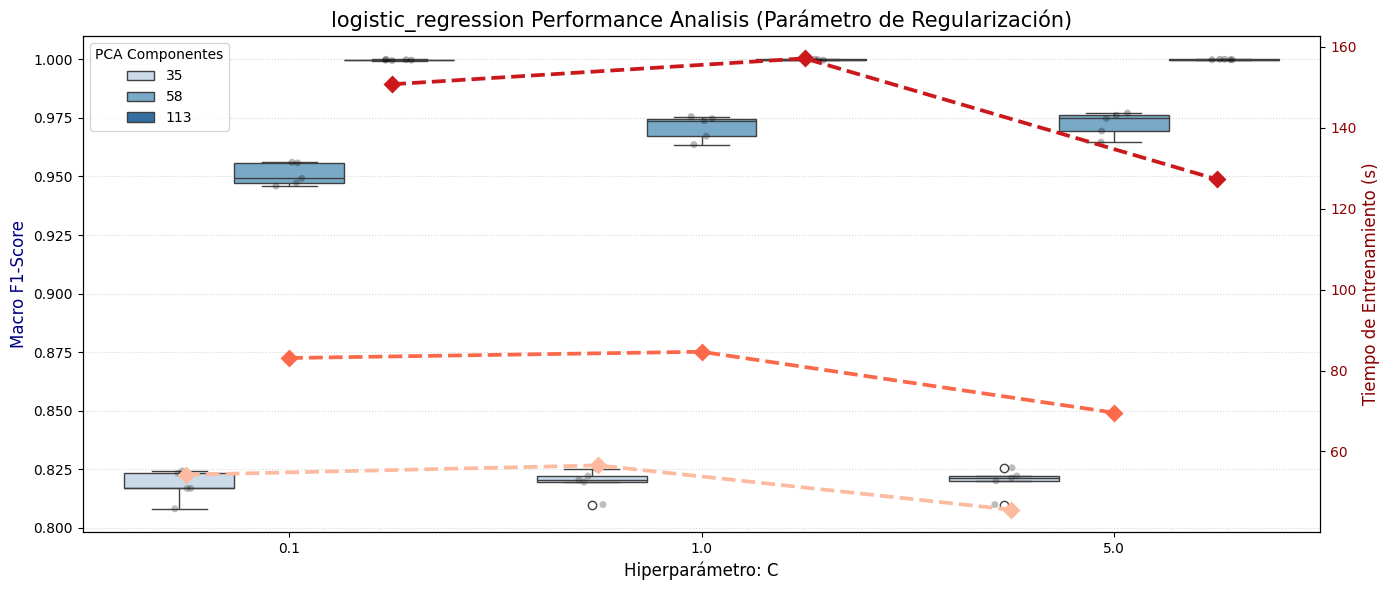

In [86]:
# --- Logistic Regression Analysis ---

lr_results = results_df[results_df['model'] == 'logistic_regression'].copy()
lr_results['PCA'] = lr_results['n_components'].astype(str)

plot_model_performance(
    df=lr_results, 
    model_name="logistic_regression", 
    x_axis_param='C', 
    title_suffix="(Parámetro de Regularización)"
)



- **Resultados**: Se observa una *dependencia crítica del F1 Score Macro con el número de componentes principales*. Con 35 componentes, el $F1 \approx 0.82$, mientras que con 58 aumenta $\approx 18\%$ y con 113 aumenta $\approx 20\%$ en comparación al obtenido con 35. Por otro lado, *el tiempo de entrenamiento incrementa notablemente al aumentar el número de componentes principales*, siendo mayor a 40s con 35 componentes, mayor a 60s con 58 y mayor a 120s con 113. *En cuanto al parámetro de regularización, la diferencia es mínima*.
- **Validación de H2**: Se refuta parcialmente. Aunque se postuló que los modelos no lineales superarían significativamente a LR, esta logra $1.0$ con 113 componentes. No obstante, el costo computacional alerta la necesidad un análisis de eficiencia en comparación con los otros modelos ($>120s$).
- **Representante**: $C=1.0$ / $PCA=113$. Es el único escenario donde LR es competitivo en precisión y estable entre folds, aunque ineficiente en tiempo.

In [72]:
rep_lr_data = get_best_representative(
    df=results_df, 
    model_name='logistic_regression', 
    best_params_dict={'C': 1.0, 'n_components': 113}
)

--- Modelo Óptimo: logistic_regression ---
Fit Time Promedio: 157.1644s
Macro F1 Promedio: 0.9999



#### B. SVM : Parámetro de Regularización `C`

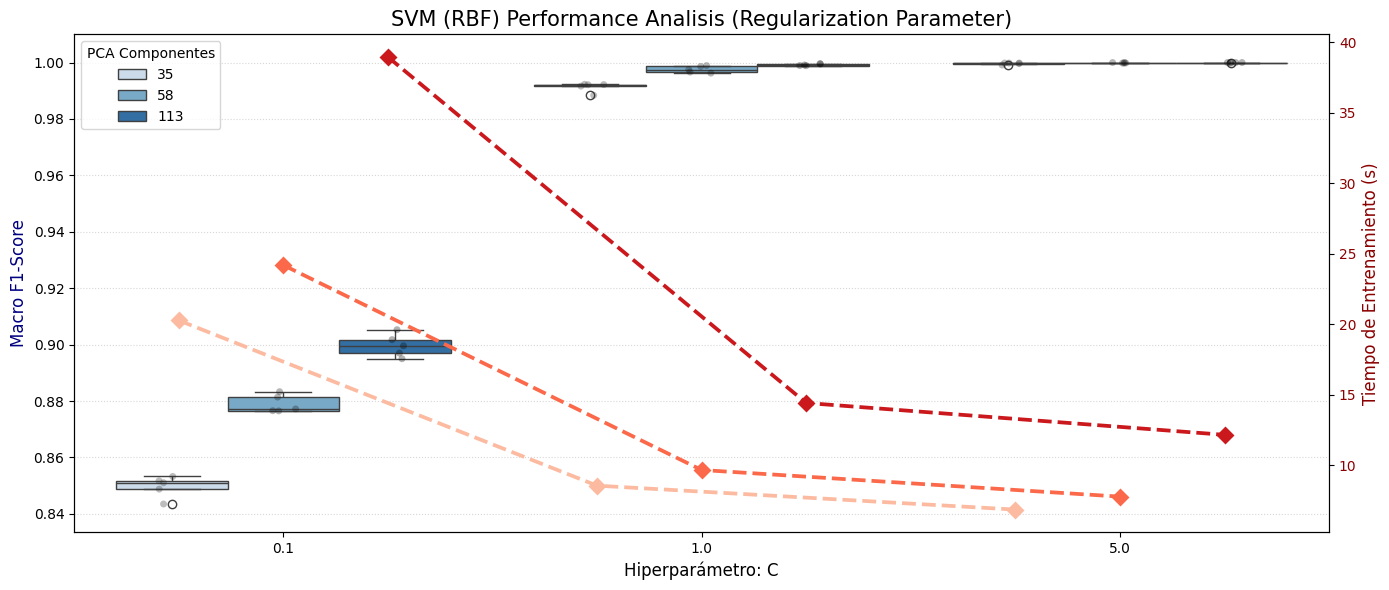

In [85]:
# --- SVM (RBF Kernel) Analysis ---
svm_results = results_df[results_df['model'] == 'svm_rbf'].copy()
svm_results['PCA'] = svm_results['n_components'].astype(str)

plot_model_performance(
    df=svm_results, 
    model_name="SVM (RBF)", 
    x_axis_param='C', 
    title_suffix="(Regularization Parameter)"
)


- **Resultados**: El gráfico muestra que con $C=1$ o $C=5$, el modelo alcanza $F1=1.0$ tanto para 58 como para 113 componentes, aunque con más estabilidad en el último caso. Curiosamente, el tiempo de entrenamiento baja drásticamente al aumentar $C$ (el optimizador converge más rápido con márgenes más rígidos). En cuanto al número de componentes principales, la diferencia decrece notablemente con el aumento de $C$.

- **Representante**: $C=1.0$ / $PCA=58$. Elegimos 58 sobre 113 componentes porque ya logra el $1.0$ reduciendo el tiempo de entrenamiento a la mitad.

In [74]:
rep_svm_data = get_best_representative(
    df=results_df, 
    model_name='svm_rbf', 
    best_params_dict={'C': 1.0, 'n_components': 58}
)

--- Modelo Óptimo: svm_rbf ---
Fit Time Promedio: 9.6801s
Macro F1 Promedio: 0.9976



#### C. kNN: Número de vecinos `n_neighbors`

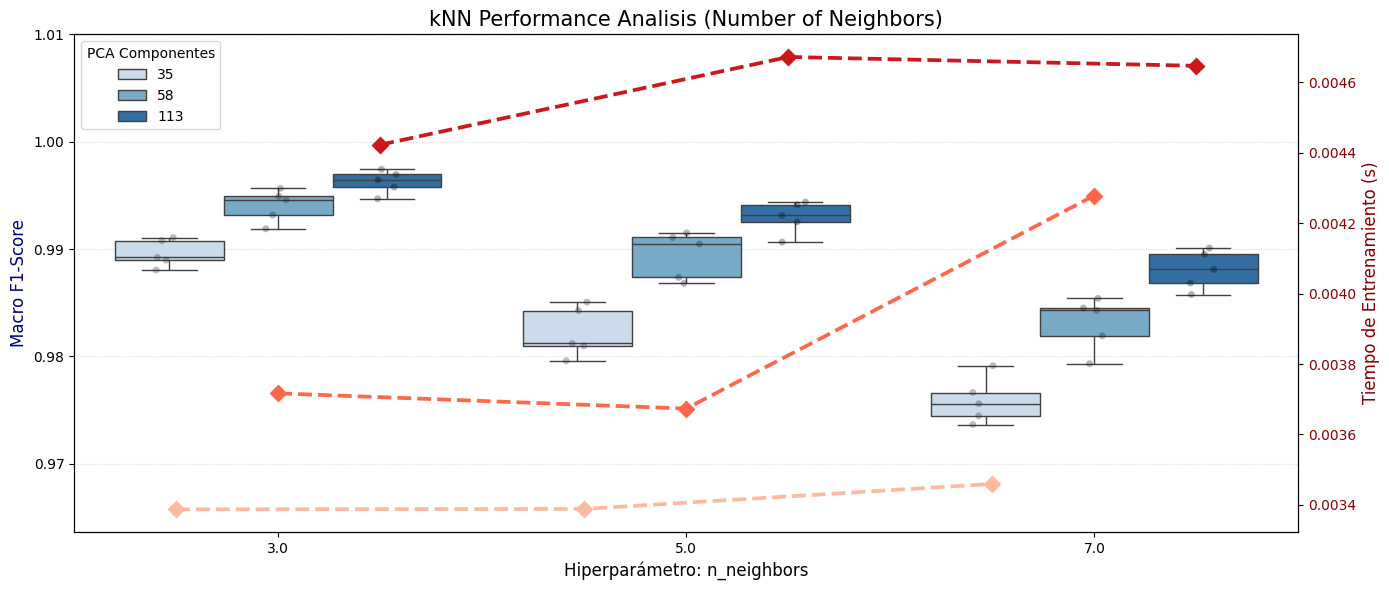

In [83]:
# --- k-Nearest Neighbors (kNN) Analysis ---

knn_results = results_df[results_df['model'] == 'knn'].copy()
knn_results['PCA'] = knn_results['n_components'].astype(str)

plot_model_performance(
    df=knn_results, 
    model_name="kNN", 
    x_axis_param='n_neighbors', 
    title_suffix="(Number of Neighbors)"
)


- **Resultados**: El rendimiento es excelente pero decae levemente al aumentar el número de vecinos. El tiempo de entrenamiento es despreciable ($<0.01s$), validando que la mayor carga de k-NN está en la inferencia, no en el ajuste.
- **Validación de H3**: Confirmada. La estructura de clústeres es tan compacta que con 3 vecinos ya se obtiene casi la perfección.
- **Representante**: $n\_neighbors=3$ / $PCA=113$. Dado que el tiempo de entrenamiento es casi nulo, priorizamos el ligero extra de precisión de las 113 componentes.

In [77]:
rep_knn_data = get_best_representative(
    df=results_df, 
    model_name='knn', 
    best_params_dict={'n_neighbors': 3, 'n_components': 113}
)

--- Modelo Óptimo: knn ---
Fit Time Promedio: 0.0044s
Macro F1 Promedio: 0.9963



#### D. RF: Número de estimadores y profundidad del árbol

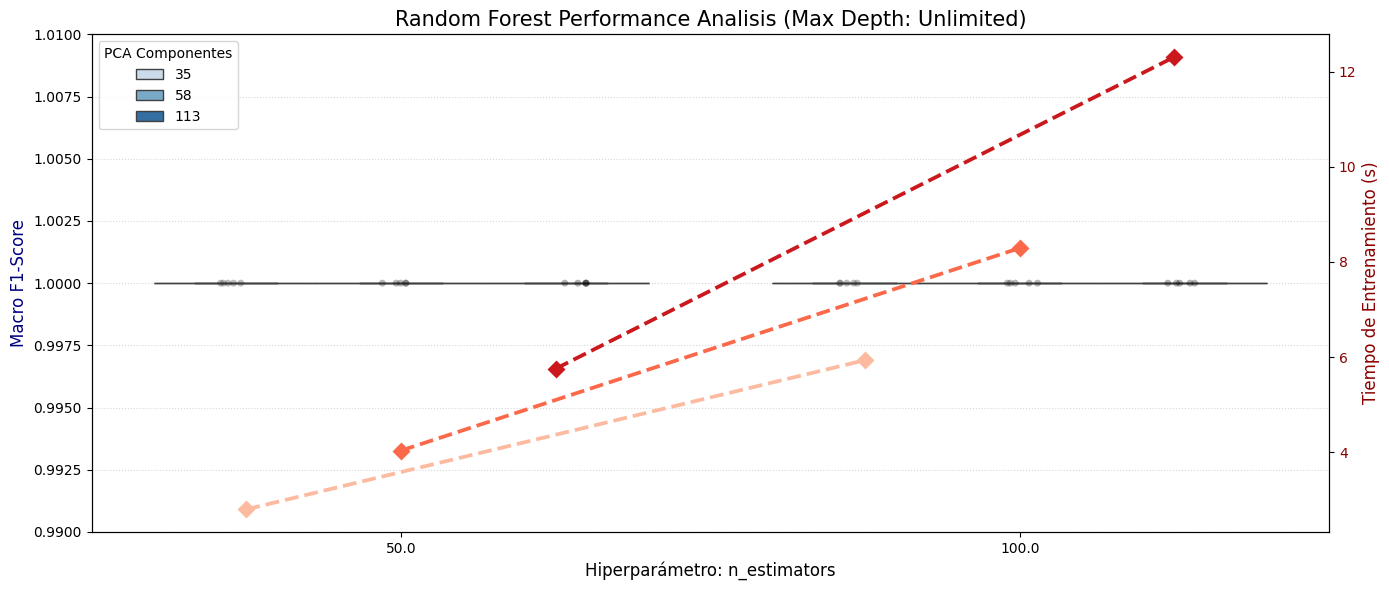

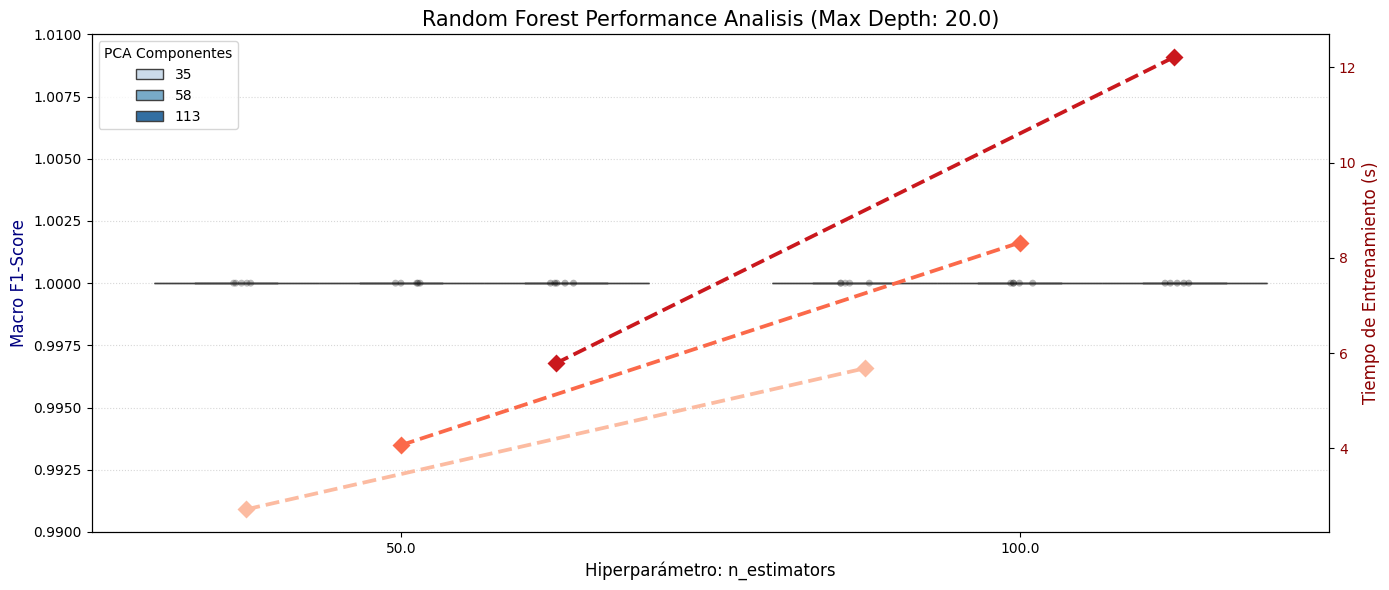

In [78]:
# --- Random Forest Analysis ---

rf_results = results_df[results_df['model'] == 'rf'].copy()
rf_results['max_depth'] = rf_results['max_depth'].fillna('Unlimited') 
rf_results['PCA'] = rf_results['n_components'].astype(str)

# We iterate through unique depths to analyze how tree complexity affects performance
depth_values = rf_results['max_depth'].unique()

for depth in depth_values:
    subset = rf_results[rf_results['max_depth'] == depth]
    
    plot_model_performance(
        df=subset, 
        model_name="Random Forest", 
        x_axis_param='n_estimators', 
        title_suffix=f"(Max Depth: {depth})"
    )


- **Resultados**: Es el modelo más robusto. Todas las configuraciones (incluso con solo 35 componentes y profundidad 20) logran un $F1=1.0$ absoluto. Variar la profundidad es indiferente en los resultados. 
- **Eficiencia**: Doblar los árboles ($100$) dobla el tiempo sin ninguna ganancia en $F1$. Quizá podemos mantener el $F1$ disminuyendo el tiempo de entrenamiento.
- **Representante**: $n\_estimators=50$ / $max\_depth=20$ / $PCA=35$. Aplicando la Navaja de Ockham, es el representante más eficiente: mínima dimensionalidad y menor número de árboles.

In [79]:
rep_rf_data = get_best_representative(
    df=results_df, 
    model_name='rf', 
    best_params_dict={'n_estimators': 50, 'max_depth': 20, 'n_components': 35}
)

--- Modelo Óptimo: rf ---
Fit Time Promedio: 2.7219s
Macro F1 Promedio: 1.0000



#### E. MLP: Tamaño de Capas Ocultas

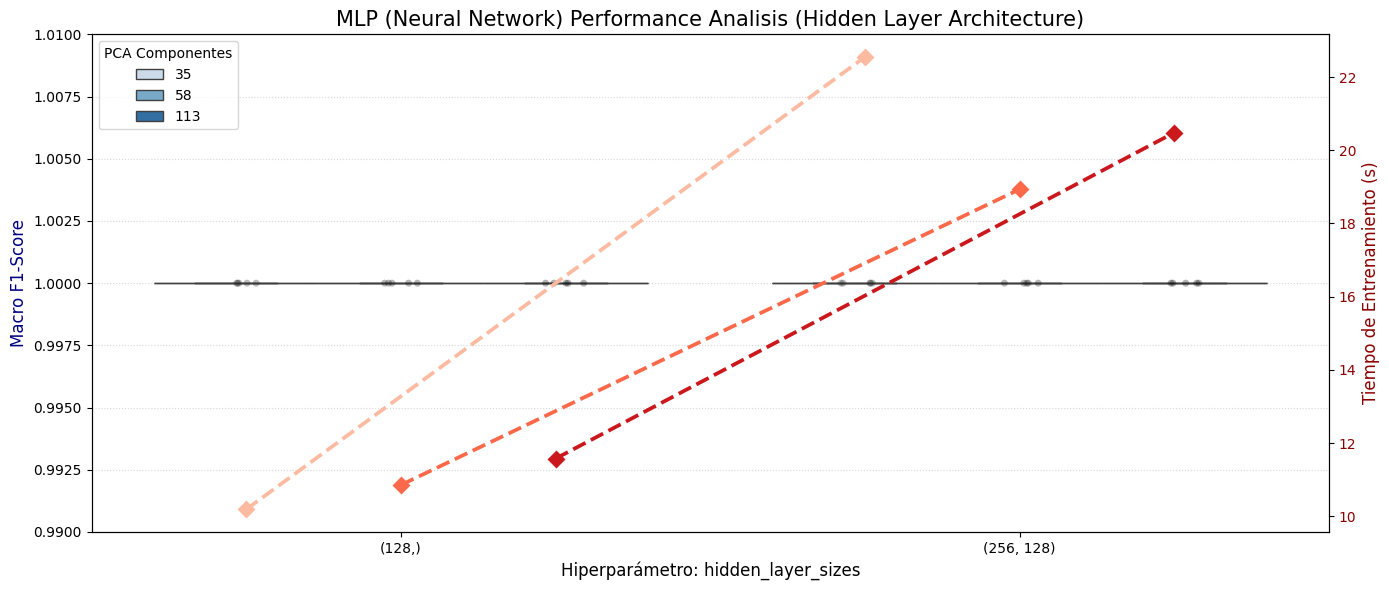

In [84]:
# --- Multi-Layer Perceptron (MLP) Analysis ---

mlp_results = results_df[results_df['model'] == 'mlp'].copy()
mlp_results['PCA'] = mlp_results['n_components'].astype(str)

plot_model_performance(
    df=mlp_results, 
    model_name="MLP (Neural Network)", 
    x_axis_param='hidden_layer_sizes', 
    title_suffix="(Hidden Layer Architecture)"
)


- **Resultados**: Al igual que RF, el MLP satura en $1.0$ rápidamente. La arquitectura simple $(128,)$ es tan efectiva como la profunda $(256, 128)$.
- **Representante**: $layers=(128,)$ / $PCA=35$. Es el representante ideal por su baja latencia y mínimo uso de memoria comparado con las versiones más profundas.

In [82]:
rep_mlp_data = get_best_representative(
    df=results_df, 
    model_name='mlp', 
    best_params_dict={'hidden_layer_sizes': (128,), 'n_components': 35}
)

--- Modelo Óptimo: mlp ---
Fit Time Promedio: 10.1911s
Macro F1 Promedio: 1.0000



#### Conclusión del Análisis Intra-Modelo

La hipótesis H1 se cumple para modelos lineales (LR), pero los modelos no lineales y ensambles (SVM para $C=5$, RF, MLP) demuestran ser inmunes a la reducción de dimensionalidad agresiva, manteniendo un $1.0$ incluso con 35 componentes.

La hipótesis H2 se cumple parcialmente pues en regresión logística se logra un $1.0$, aunque con notable diferencia de tiempo de entrenamiento.

La hipótesis H3 queda validada por el análisis previo de los resultados del modelo kNN.

Para la comparativa Inter-Modelo, estos son los configuraciones óptimas, seleccionadas bajo el criterio de Máximo F1 con Mínimo Costo (Tiempo/PCA):

| Modelo | Configuración | PCA | F1_Score Macro promedio | Tiempo Fit promedio |
|--------|------|--------|--------|--------|
| LR | `C`=1 | 113 | 0.99 |157.16 |
| SVM | `C`=1 | 58 | 0.99 | 9.68 |
| kNN | `n_neighbors`= 3 | 113 | 0.99 | 0.0044 |
| RF | `n_estimators`= 100, `max_depth`=20 | 35 | 1.00 | 5.68 |
| MLP | `hidden_layer_sizes`= (128,) | 35 | 1.00 | 10.19 |


### 5.2 Análisis Inter-Modelos (Selección del Modelo Óptimo)

El objetivo es identificar qué arquitectura ofrece el mejor balance entre la Hipótesis de Reducción (H1) y la Eficiencia Operativa tanto en tiempo como en memoria.

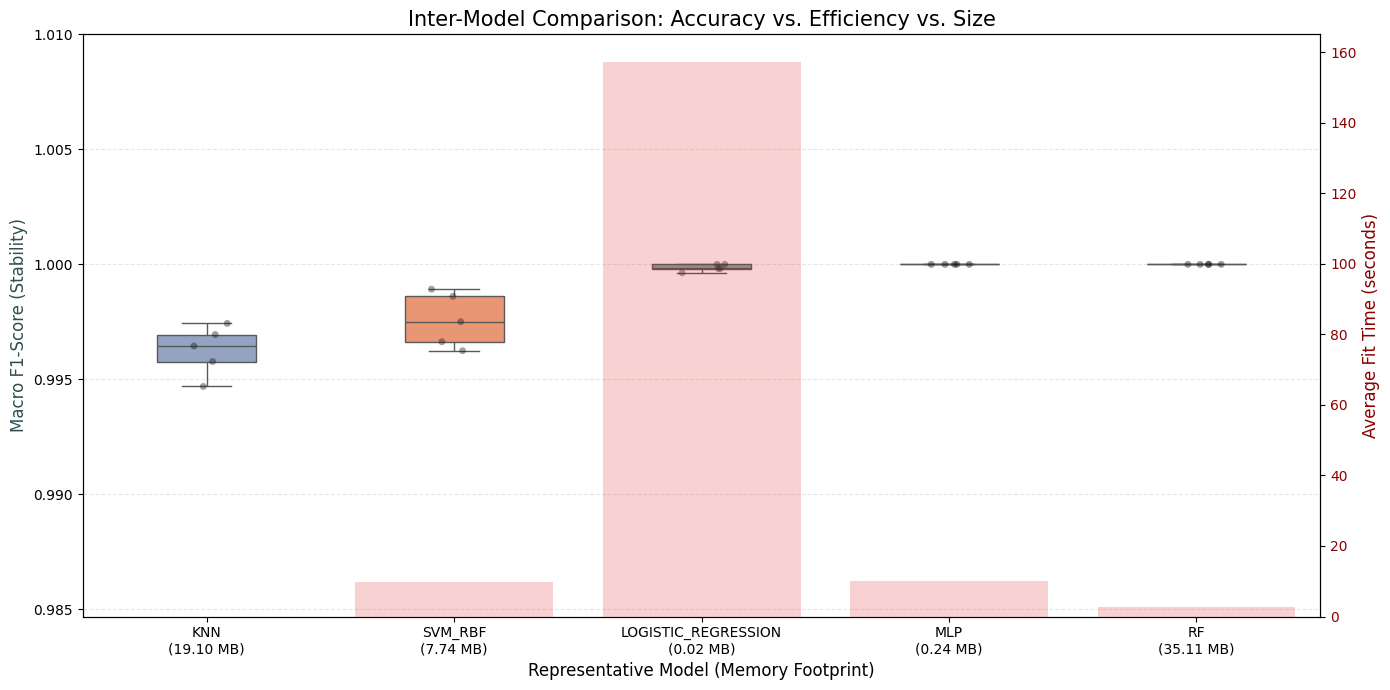

In [87]:
# --- FINAL INTER-MODEL COMPARISON ---
# Purpose: Compare the best configurations of each architecture to select the production model.

# Consolidate best representatives from all models
inter_model_df = pd.concat([
    rep_lr_data, 
    rep_svm_data, 
    rep_knn_data, 
    rep_rf_data, 
    rep_mlp_data
], ignore_index=True)

# Feature Engineering for Visualization: Combine model name with its memory footprint
size_avg_map = inter_model_df.groupby('model')['model_size_mb'].mean().to_dict()
inter_model_df['model_label'] = inter_model_df['model'].apply(
    lambda x: f"{x.upper()}\n({size_avg_map[x]:.2f} MB)"
)

performance_order = inter_model_df.groupby('model_label')['macro_f1'].mean().sort_values().index

fig, ax1 = plt.subplots(figsize=(14, 7))

# --- Left Axis: F1-SCORE (Boxplot for stability + Stripplot for individual folds) ---
sns.boxplot(data=inter_model_df, x='model_label', y='macro_f1', order=performance_order,
            palette='Set2', hue='model_label', legend=False, ax=ax1, width=0.4)
sns.stripplot(data=inter_model_df, x='model_label', y='macro_f1', order=performance_order,
              palette='dark:black', hue='model_label', legend=False, alpha=0.4, ax=ax1)

ax1.set_ylabel("Macro F1-Score (Stability)", fontsize=12, color='darkslategrey')
ax1.set_ylim(inter_model_df['macro_f1'].min() - 0.01, 1.01)
ax1.set_xlabel("Representative Model (Memory Footprint)", fontsize=12)

# --- Right Axis: EFFICIENCY (Mean Training Time) ---
ax2 = ax1.twinx()
sns.barplot(data=inter_model_df, x='model_label', y='fit_time', order=performance_order,
            alpha=0.2, ax=ax2, color='red', errorbar=None)
ax2.set_ylabel("Average Fit Time (seconds)", fontsize=12, color='darkred')
ax2.tick_params(axis='y', labelcolor='darkred')

plt.title("Inter-Model Comparison: Accuracy vs. Efficiency vs. Size", fontsize=15)
ax1.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

Al contrastar el rendimiento inter-modelo, se identifica al Perceptrón Multicapa (MLP) como la arquitectura más eficiente para este problema. Aunque el Random Forest alcanza una precisión idéntica, el MLP logra equilibrar un tiempo de entrenamiento competitivo con una huella de memoria significativamente menor (apenas 0.24 MB frente a los >7 MB de otros modelos). 

Es destacable su estabilidad perfecta entre folds (varianza nula en el F1-Score), lo que a priori parece una alta capacidad de generalización sobre el espacio latente del PCA (35 componentes), que deberá ser puesto aprueba con el conjunto de test. A diferencia del k-NN, que requiere una carga de memoria lineal respecto al dataset, el MLP ofrece un modelo ligero, ideal para una implementación de tiempo real con bajo consumo de recursos. Además representa un equilibrio entre la memoria que ocupa el clasificador y su tiempo de entrenamiento, al contrario del modelo de regresión logística que extremiza ambos parámetros.

### 5.3 Análisis de Errores del Modelo Seleccionado

Tal como se observa en los reportes del F1-Score, el modelo MLP logró una clasificación perfecta. Con el fin de verificar estos resultados y asegurar que ninguna seña específica (como la 'M' o la 'N') estuviera siendo clasificada erróneamente, visualizamos la matriz de confusión promedio a través de los 5 folds de la validación cruzada. La diagonal resultante confirma que las fronteras de decisión están perfectamente definidas en el espacio de 35 componentes principales, al menos durante la etapa de validación.

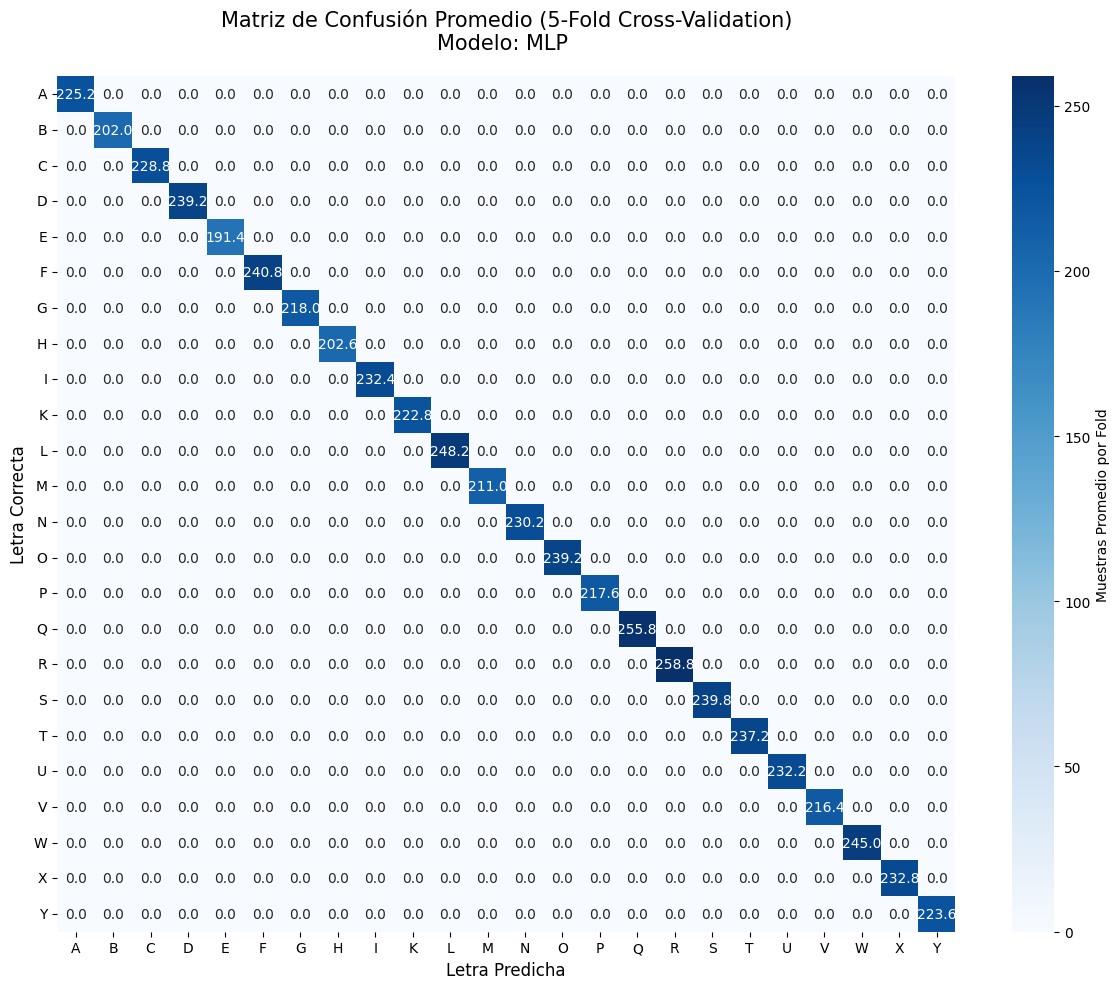

In [101]:
class_labels = [chr(i + 65) for i in range(25) if i != 9] 
mean_cm = np.mean(rep_mlp_data.confusion_matrix, axis=0)

plt.figure(figsize=(12, 10))

# We use a heatmap to show the concentration of predictions
sns.heatmap(
    mean_cm, 
    annot=True,          
    fmt='.1f',           
    cmap='Blues',        
    xticklabels=class_labels, 
    yticklabels=class_labels,
    cbar_kws={'label': 'Muestras Promedio por Fold'}
)

plt.title("Matriz de Confusión Promedio (5-Fold Cross-Validation)\nModelo: MLP ", fontsize=15, pad=20)
plt.xlabel("Letra Predicha", fontsize=12)
plt.ylabel("Letra Correcta", fontsize=12)

plt.xticks(rotation=0)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

## 6. Conclusión

Tras un análisis exhaustivo de cinco arquitecturas diferentes y sus respectivos hiperparámetros, se ha seleccionado el Perceptrón Multicapa (MLP) como el modelo definitivo para este proyecto.

**Justificación Técnica:**
- Rendimiento Superior y Estabilidad: El modelo MLP alcanzó un F1-Score Macro de 1.0 de manera consistente a través de los 5 folds de validación cruzada. La matriz de confusión promedio confirma que no existe confusión entre señas morfológicamente similares (como la 'M' y la 'N'), validando que el espacio de características reducido mediante PCA (35 componentes) es suficiente para este conjunto de datos.

- Eficiencia de Almacenamiento: Este es el factor determinante. Mientras que modelos como Random Forest o SVM requieren más de 7 para almacenar sus estructuras, el MLP seleccionado ocupa apenas 0.24 MB. Esta reducción en el tamaño del modelo es crítica para despliegues en dispositivos de baja potencia o aplicaciones móviles.

- Compromiso entre Recursos: Aunque su huella de memoria es superior al de la Regresión Logística, la ganancia en capacidad de generalización y su tiempo de entrenamiento justifican el costo computacional.

**Decisión Final:** Se procede al entrenamiento del MLP (arquitectura de 128 neuronas en capa oculta) utilizando el dataset completo, para su posterior evaluación final contra el conjunto de test (Hold-out set).